# Game-level EDA

🎯 Goal: understand what drives high-quality board games.

Focus:
1. Which intrinsic game features drive ratings?
2. Do mechanics/themes matter?
3. Popular vs loved

### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path

import matplotlib.pyplot as plt

### Load and join data

In [2]:
DATA_DIR = Path("../raw_data")

games = pd.read_csv(DATA_DIR / "games.csv")
mechanics = pd.read_csv(DATA_DIR / "mechanics.csv")
themes = pd.read_csv(DATA_DIR / "themes.csv")
subcategories = pd.read_csv(DATA_DIR / "subcategories.csv")

In [3]:
df = (
    games
    .merge(mechanics, on="BGGId", how="left")
    .merge(themes, on="BGGId", how="left")
    .merge(subcategories, on="BGGId", how="left")
)

df.shape

(21925, 432)

## Q1. Which intrinsic game features drive ratings?

In [4]:
# Explore the target

df["BayesAvgRating"].describe()

count    21925.000000
mean         5.685673
std          0.365311
min          3.574810
25%          5.510300
50%          5.546540
75%          5.679890
max          8.514880
Name: BayesAvgRating, dtype: float64

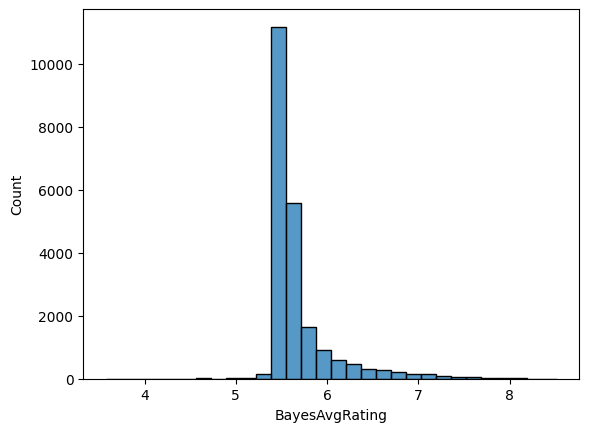

In [5]:
sns.histplot(df["BayesAvgRating"], bins=30);

**Target distribution**

- Ratings are tight and right-skewed
- Most games cluster around 5.5-6
- Very few below 5 or above 8

👉 Good vs Bad games aren't that far apart numerically, so small differences in scores will matter

### Complexity

Do more complex games get better ratings?

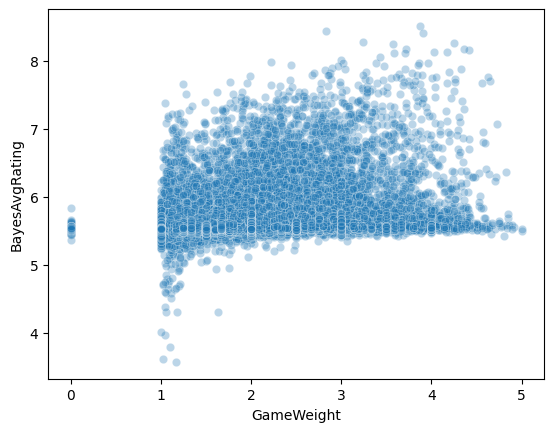

In [6]:
sns.scatterplot(data=df, x="GameWeight", y="BayesAvgRating", alpha=0.3);

**Game complexity**

- Slight upward trend but huge spread.

👉 Complexity does not always equal quality, may be mildly associated

### Number of games owned

Do games owned by more people have higher ratings?

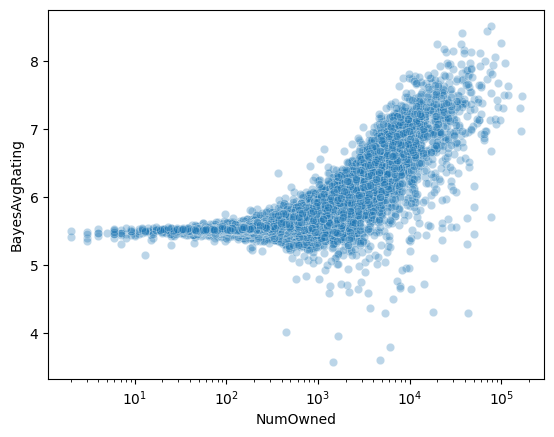

In [7]:
sns.scatterplot(data=df, x="NumOwned", y="BayesAvgRating", alpha=0.3)
plt.xscale("log");

**Number of Games Owned**

- Clear upward curve: higher ownership -> higher ratings

👉 Popularity (NumOwned) is strongly associated with rating. This likely reflects a reinforcing feedback loop, where higher-rated games gain visibility and adoption, leading to more ratings and sustained high scores.

### Number of players

Are solo / small / large group games rated differently?

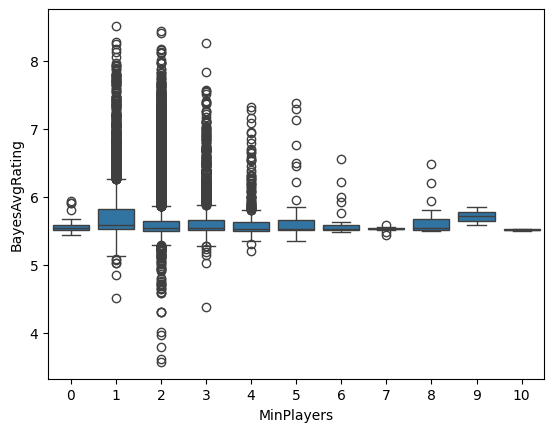

In [8]:
sns.boxplot(data=df, x="MinPlayers", y="BayesAvgRating");

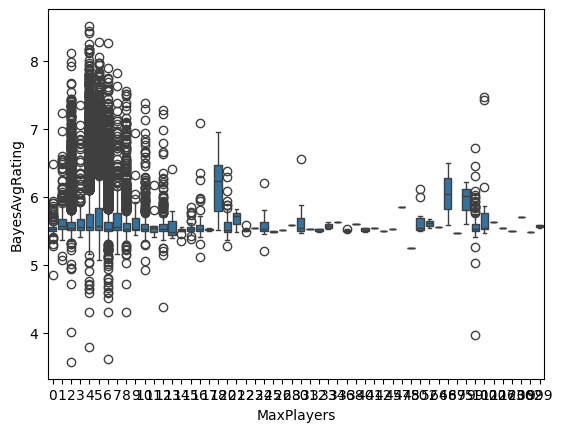

In [9]:
sns.boxplot(data=df, x="MaxPlayers", y="BayesAvgRating");

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_259/2908624487.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["player_range"] = df["MaxPlayers"] - df["MinPlayers"]


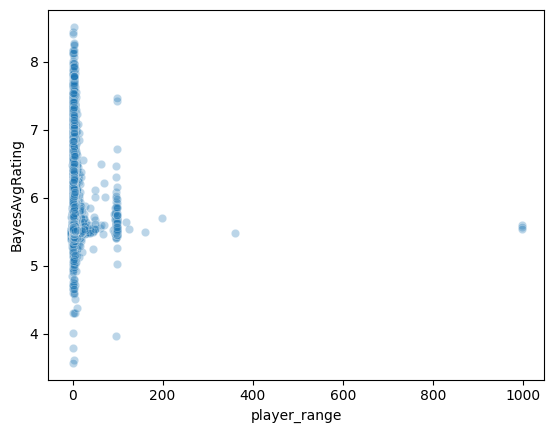

In [10]:
df["player_range"] = df["MaxPlayers"] - df["MinPlayers"]

sns.scatterplot(data=df, x="player_range", y="BayesAvgRating", alpha=0.3);

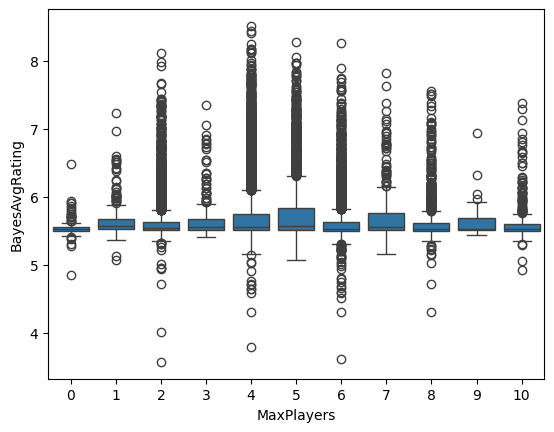

In [11]:
df_filtered = df[df["MaxPlayers"] <= 10]

sns.boxplot(data=df_filtered, x="MaxPlayers", y="BayesAvgRating");

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_259/3074881033.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["player_group"] = df["MaxPlayers"].apply(player_group)


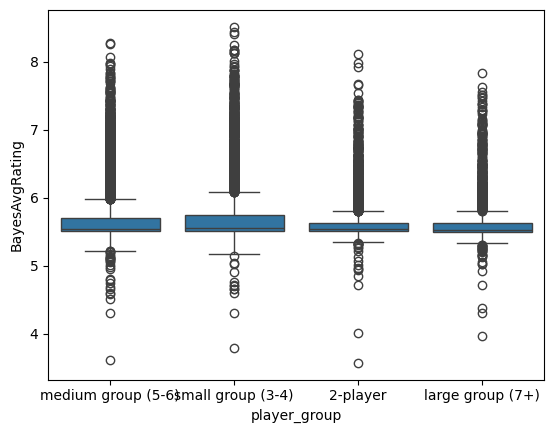

In [12]:
def player_group(x):
    if x <= 2:
        return "2-player"
    elif x <= 4:
        return "small group (3-4)"
    elif x <= 6:
        return "medium group (5-6)"
    else:
        return "large group (7+)"

df["player_group"] = df["MaxPlayers"].apply(player_group)

sns.boxplot(data=df, x="player_group", y="BayesAvgRating");

**Number of Players**

- Most games are 1-4 players
- Ratings are very similar across groups
- Small group games (3–4 players) show a slight tendency toward higher ratings, though the effect is weak.

👉 Player group size does not appear to be a strong driver of rating

### Game type (subcategories)

Which types of games tend to rate higher?

In [13]:
subcat_cols = subcategories.columns.drop("BGGId")

results = []

for col in subcat_cols:
    avg = df[df[col] == 1]["BayesAvgRating"].mean()
    results.append((col, avg))

subcat_df = pd.DataFrame(results, columns=["subcategory", "avg_rating"])
subcat_df.sort_values("avg_rating", ascending=False)

,subcategory,avg_rating
2,Territory Building,5.909820
0,Exploration,5.843361
1,Miniatures,5.813888
5,Puzzle,5.745546
6,Collectible Components,5.695522
3,Card Game,5.671017
8,Print & Play,5.633065
4,Educational,5.612941
7,Word Game,5.599703
9,Electronic,5.557387


**Subcategories**

👉 Subcategory has a weak relationship with rating

### Age Group

What impact does recommended age group have?

Note we use the community and not manufacturer recommendation, as this value should better reflect what players think is appropriate.

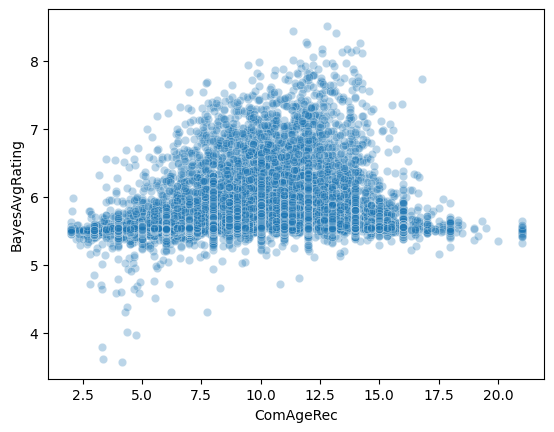

In [14]:
sns.scatterplot(data=df, x="ComAgeRec", y="BayesAvgRating", alpha=0.3);

**Age group**

- Most games sit between ~5–7 rating regardless of age
- There’s a slight “bulge” around:
  - age ~10–14
  - slightly higher ratings (~6–7.5)
- Very young (2–5) and very high (18+) look flatter / slightly lower
- Lots of spread and high overlap

👉 Community-recommended age shows only a weak relationship with rating, with games aimed at older audiences trending slightly higher but with significant variability.

### Playing time

What impact does playing time have?

Note that again, we use the community and not manufacturer recommendation.

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_259/3810662053.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ComAvgPlaytime"] = (df["ComMinPlaytime"] + df["ComMaxPlaytime"]) / 2


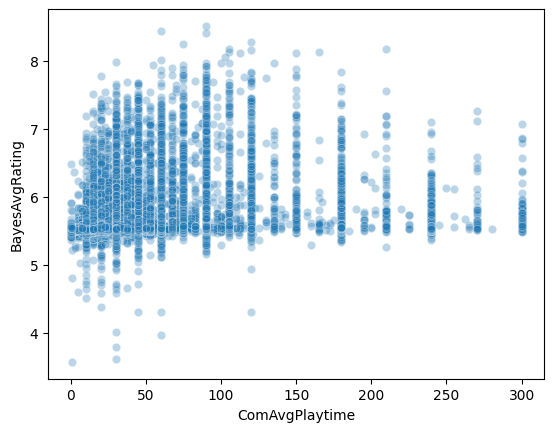

In [15]:
df["ComAvgPlaytime"] = (df["ComMinPlaytime"] + df["ComMaxPlaytime"]) / 2
df_play = df[df["ComAvgPlaytime"] <= 300]

sns.scatterplot(data=df_play, x="ComAvgPlaytime", y="BayesAvgRating", alpha=0.3);

**Playing time**

- Most games are short-medium length (30 - 120 min)
- At almost every playtime, ratings are spread ~5 - 7+
- There's a slight trend of more high-rated games in the ~60–120 range, and fewer very high ratings at extreme long playtimes - but it's weak

👉 Playtime shows no strong relationship with rating.

Most highly rated games appear to fall within a typical playtime range (~60–120 minutes), though this likely reflects where most games are concentrated rather than a causal effect.

### 🙋‍♀️ Summary: What drives ratings?

- **Ratings** are tightly clustered (~5.5–6.5), meaning differences between games are relatively small.
- **Game complexity** shows a slight positive relationship with rating, though with significant variance. Complexity alone is not a strong predictor of quality.
- **Popularity** (e.g. number of owners) is strongly associated with rating. This likely reflects a reinforcing feedback loop, where highly rated games gain visibility and adoption, leading to more ratings and sustained high scores.
- **Player count** (both minimum and maximum) shows little relationship with rating. Games across different player ranges have very similar distributions.
- **Subcategory** shows modest variation in average ratings, but differences are small and overlapping. Genre alone is not a strong driver of quality.
- **Community-recommended age** shows a weak relationship with rating, with games aimed at older audiences trending slightly higher, though with substantial variability.
- **Average playtime** shows little clear relationship with rating. Most games fall within a typical range (~30–120 minutes), and ratings vary widely across all playtimes.

👉 **No single intrinsic feature strongly explains rating**, suggesting that game quality is driven by a combination of factors rather than any individual characteristic.

## Q2. Do mechanics/themes matter?

We want to answer: "Do games with this mechanic (or theme) have higher ratings than those without?"

First, create a reusable function to count how many games have a specific feature and filter out rare features that would affect the average unhelpfully.

In [16]:
def get_feature_importance(df, feature_columns, target="BayesAvgRating", min_count=50):

    # create list to store results
    results = []

    # loop through each column
    for col in feature_columns:
        # skip BGGId
        if col == "BGGId":
            continue

        # count how many games have this feature
        count = df[col].sum()

        # filter out rare features
        if count >= min_count:
            # and get average rating for the rest
            mean_rating = df[df[col] == 1][target].mean()
            # store result
            results.append((col, count, mean_rating))

    # create and sort dataframe
    result_df = pd.DataFrame(results, columns=["feature", "count", "avg_rating"])
    result_df = result_df.sort_values(by="avg_rating", ascending=False)

    return result_df

Then, use the function to convert the binary mechanic and theme data into a usable signal.

In [ ]:
mechanic_cols = [col for col in mechanics.columns if col != "BGGId"]

mechanic_df = get_feature_importance(df, mechanic_cols)

In [27]:
mechanic_df.head(10)

,feature,count,avg_rating
54,Tech Trees / Tech Tracks,58,6.676247
72,TableauBuilding,175,6.661934
23,Income,98,6.551642
48,Map Addition,53,6.520252
64,End Game Bonuses,180,6.502051
83,Action Retrieval,62,6.460143
13,Victory Points as a Resource,71,6.431745
73,Grid Coverage,53,6.370559
10,Market,79,6.311498
82,Contracts,137,6.302673


In [19]:
mechanic_df.tail(10)

,feature,count,avg_rating
6,Hexagon Grid,2438,5.653493
5,Trick-taking,402,5.645890
46,Memory,1015,5.634525
50,Ratio / Combat Results Table,308,5.622202
55,Chit-Pull System,264,5.617761
86,Physical,459,5.604069
63,Zone of Control,276,5.599653
16,Pattern Recognition,560,5.597570
85,Dexterity,1105,5.587276
26,Roll / Spin and Move,1371,5.527252


In [22]:
themes_cols = [col for col in themes.columns if col != "BGGId"]

themes_df = get_feature_importance(df, themes_cols)

themes_df.head(10)

,feature,count,avg_rating
66,Theme_Colonial,76,6.344606
72,Theme_Art,61,6.159660
10,Civilization,350,6.009257
53,City Building,549,6.001914
76,Theme_Tropical,55,5.977478
6,Industry / Manufacturing,297,5.976304
64,Theme_Post-Apocalyptic,89,5.952034
73,Theme_Archaeology / Paleontology,61,5.946633
25,Farming,251,5.934575
16,Renaissance,272,5.932493


In [24]:
themes_df.tail(10)

,feature,count,avg_rating
31,Mature / Adult,161,5.627296
50,Number,195,5.620957
46,Napoleonic,324,5.616329
49,American Civil War,246,5.611991
43,Humor,1228,5.611743
12,Movies / TV / Radio theme,1067,5.605130
40,Racing,622,5.601592
55,Math,156,5.585637
52,Music,88,5.572310
51,Trivia,588,5.529409


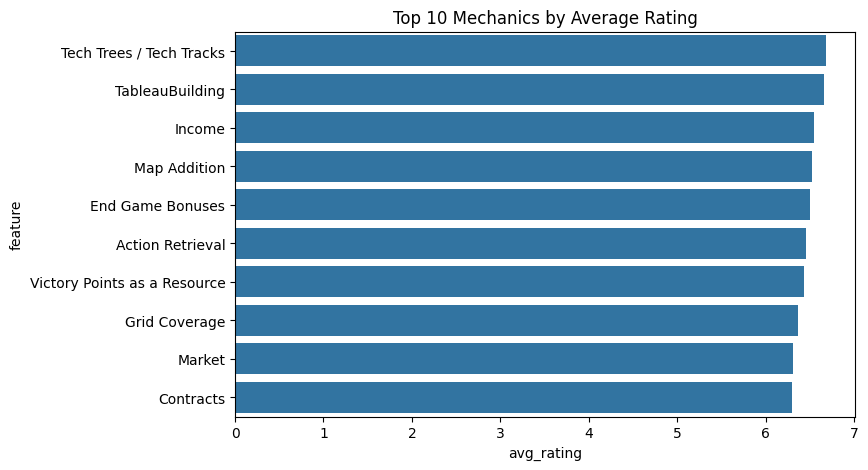

In [25]:
top_mechanics = mechanic_df.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_mechanics, x="avg_rating", y="feature")
plt.title("Top 10 Mechanics by Average Rating")
plt.show()

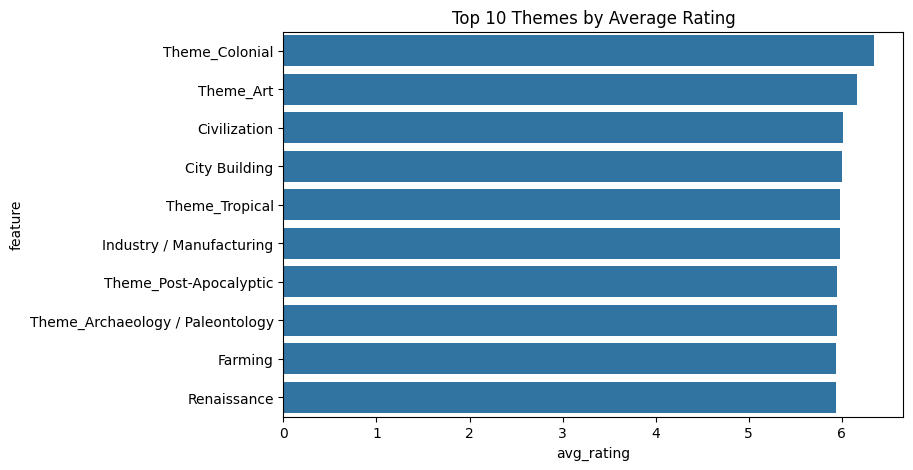

In [26]:
top_themes = themes_df.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_themes, x="avg_rating", y="feature")
plt.title("Top 10 Themes by Average Rating")
plt.show()

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_259/2369321308.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["num_mechanics"] = mechanics.drop(columns=["BGGId"]).sum(axis=1)


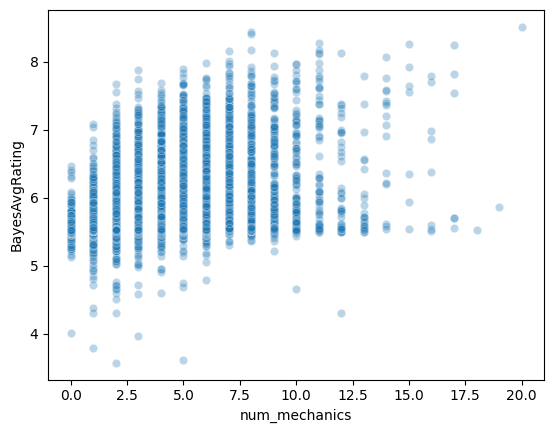

In [28]:
df["num_mechanics"] = mechanics.drop(columns=["BGGId"]).sum(axis=1)

sns.scatterplot(data=df, x="num_mechanics", y="BayesAvgRating", alpha=0.3);

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_259/3049240516.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["num_themes"] = themes.drop(columns=["BGGId"]).sum(axis=1)


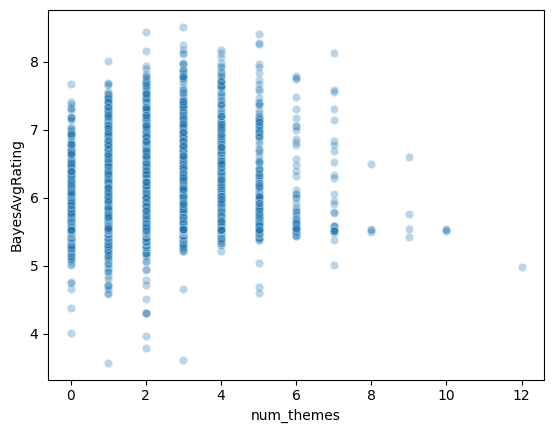

In [29]:
df["num_themes"] = themes.drop(columns=["BGGId"]).sum(axis=1)

sns.scatterplot(data=df, x="num_themes", y="BayesAvgRating", alpha=0.3);

### 🙋‍♀️ Summary: Do mechanics and themes matter?

**Mechanics**

- Mechanics show more variation in average ratings than broader features explored in Q1, suggesting that **specific gameplay elements contribute more meaningfully** to perceived quality.
- **Higher-rated mechanics tend to involve strategic depth and system-building** (e.g. tableau building, tech trees, resource generation, end-game scoring), while lower-rated mechanics are more often associated with simpler or more luck-based gameplay (e.g. roll-and-move, dexterity, memory).
- ⚠️ However, differences remain moderate, and some top-ranked mechanics are based on relatively small sample sizes. Additionally, many mechanics represent overlapping concepts, so results should be interpreted as directional rather than definitive.

**Themes**

- **Themes show weaker variation than mechanics**. While more “serious” or strategic themes (e.g. civilization, industry) trend slightly higher than lighter themes (e.g. trivia, music), differences are modest and overlapping.

**Complexity of mechanics and themes**

- **The number of mechanics per game shows a moderate positive relationship with rating**. Games with more mechanics tend to have higher potential ratings, suggesting that greater systemic depth may contribute to perceived quality.
- In contrast, the number of themes shows little clear relationship with rating, indicating that thematic richness alone does not strongly influence game quality.

👉 Overall, gameplay structure (mechanics and their combination) appears to be a more meaningful driver of ratings than thematic content, though no single feature fully explains game quality.

## Q3. Popular vs Loved

Are highly rated games actually the same as popular games?

Are some games widely owned vs deeply loved?

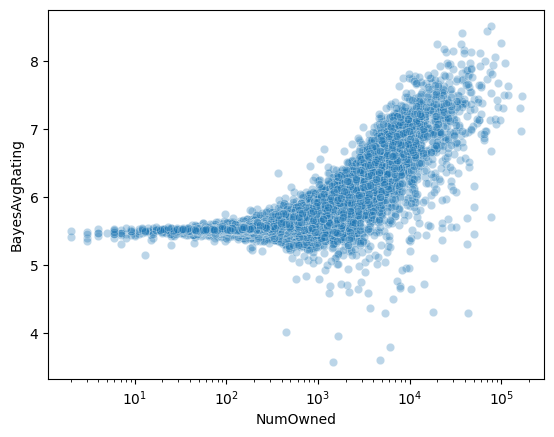

In [30]:
sns.scatterplot(
    data=df,
    x="NumOwned",
    y="BayesAvgRating",
    alpha=0.3
)

plt.xscale("log")

*You rarely see very highly rated games that are not popular*

*You do see popular games that are not highly rated*

#### 🙋‍♀️ Why does this matter?

- Popularity (number of owners) shows a strong non-linear relationship with rating. Highly rated games are almost always widely owned, while less popular games rarely achieve high ratings.

- However, high ownership does not guarantee high ratings, with many widely owned games remaining average. This suggests a reinforcing feedback loop where visibility and adoption contribute to higher ratings, rather than popularity being purely a reflection of intrinsic quality.

Create simple segments:

In [ ]:
# Define segments (equal-sized groups)
df["popularity"] = pd.qcut(df["NumOwned"], q=3, labels=["low", "medium", "high"])
df["rating_band"] = pd.qcut(df["BayesAvgRating"], q=3, labels=["low", "medium", "high"])

# Cross-tab popularity and rating band
pd.crosstab(df["popularity"], df["rating_band"])

rating_band,low,medium,high
popularity,,,
low,4360,2911,66
medium,2323,3646,1317
high,627,750,5925


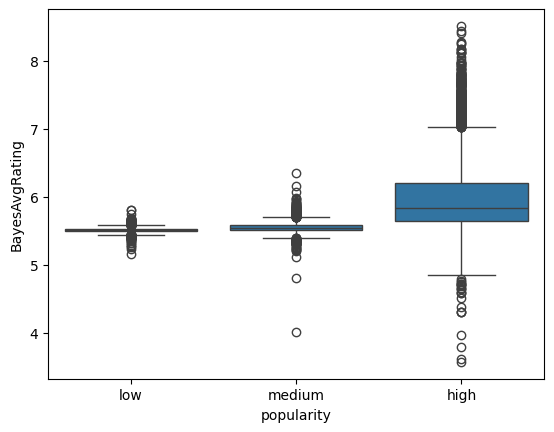

In [34]:
sns.boxplot(data=df, x="popularity", y="BayesAvgRating");

### 🙋‍♀️ Summary: Popular vs Loved

- **Popularity (number of owners) shows a strong, non-linear relationship with rating**. Highly rated games are almost always widely owned, while less popular games rarely achieve high ratings.
- **The relationship is asymmetric**: while most highly popular games achieve high ratings, popularity alone does not guarantee quality, with some widely owned games remaining average.
- Low-popularity games are overwhelmingly concentrated in the low-to-medium rating bands, with very few achieving high ratings. This suggests that **“hidden gems” exist but are relatively rare**.
- Medium-popularity games span all rating bands, acting as a transition between niche and widely adopted titles.
- The **distribution supports the presence of a reinforcing feedback loop**, where visibility and adoption increase the likelihood of receiving more ratings and sustaining higher scores.

👉 Overall, highly rated games tend to also be highly popular, making it difficult to disentangle intrinsic quality from exposure and adoption effects.

## Key takeaways

⭐️ **Game quality is not explained by any single feature — it’s multi-factor and noisy.**

- No single feature strongly explains game ratings. Most individual attributes (e.g. player count, themes, playtime) show weak or highly variable relationships with rating.
- Game quality appears to be multi-factor and non-linear. Relationships between features and ratings are noisy and overlapping, suggesting that combinations of features - rather than any single variable - drive outcomes.
- Gameplay structure matters more than surface characteristics. Mechanics, and particularly the number of mechanics, show a stronger relationship with rating than themes or other descriptive features.
- Popularity is strongly associated with rating, but likely confounded. Highly rated games are almost always widely owned, suggesting a reinforcing feedback loop between visibility, adoption, and ratings.
- Hidden high-quality games are rare. Low-popularity games are overwhelmingly concentrated in lower rating bands, with very few achieving high ratings.

👉 Overall, predicting game quality is a complex problem that likely requires combining multiple features and modelling non-linear relationships - making it well-suited to a machine learning approach.